In [1]:
# Set seed for reproducibility from top of file
set.seed(2026)

# Load libraries

In [2]:
# install.packages("tidyverse")
# install.packages("moments")
# install.packages("caret")
# install.packages("survival")
# install.packages("leaps")
# install.packages("glmnet")
library(tidyverse)
library(moments)
library(caret)
library(survival)
library(leaps)
library(glmnet)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.0     ✔ readr     2.2.0
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.2     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.1     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Loading required package: lattice


Attaching package: 'caret'


The following object is masked from 'package:purrr':

    lift



Attaching package: 'survival'


The following object is masked from 'package:caret':

    cluster


Loading required package: Matrix


Attaching package: 'Matrix'


The following objects are masked from 'package:tidyr':

    expand, pack, unpack


Loaded glmnet 4.1-10



# Load data / Start EDA

In [3]:
raw_df <- read.csv("METABRIC_RNA_Mutation.csv")

# Explore data
head(raw_df)

cat("Number of rows:", nrow(raw_df), "\n",
    "Number of columns:", ncol(raw_df), "\n")

colnames(raw_df)

,patient_id,age_at_diagnosis,type_of_breast_surgery,cancer_type,cancer_type_detailed,cellularity,chemotherapy,pam50_._claudin.low_subtype,cohort,er_status_measured_by_ihc,⋯,mtap_mut,ppp2cb_mut,smarcd1_mut,nras_mut,ndfip1_mut,hras_mut,prps2_mut,smarcb1_mut,stmn2_mut,siah1_mut
,<int>,<dbl>,<chr>,<chr>,<chr>,<chr>,<int>,<chr>,<dbl>,<chr>,⋯,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
1,0,75.65,MASTECTOMY,Breast Cancer,Breast Invasive Ductal Carcinoma,,0,claudin-low,1,Positve,⋯,0,0,0,0,0,0,0,0,0,0
2,2,43.19,BREAST CONSERVING,Breast Cancer,Breast Invasive Ductal Carcinoma,High,0,LumA,1,Positve,⋯,0,0,0,0,0,0,0,0,0,0
3,5,48.87,MASTECTOMY,Breast Cancer,Breast Invasive Ductal Carcinoma,High,1,LumB,1,Positve,⋯,0,0,0,0,0,0,0,0,0,0
4,6,47.68,MASTECTOMY,Breast Cancer,Breast Mixed Ductal and Lobular Carcinoma,Moderate,1,LumB,1,Positve,⋯,0,0,0,0,0,0,0,0,0,0
5,8,76.97,MASTECTOMY,Breast Cancer,Breast Mixed Ductal and Lobular Carcinoma,High,1,LumB,1,Positve,⋯,0,0,0,0,0,0,0,0,0,0
6,10,78.77,MASTECTOMY,Breast Cancer,Breast Invasive Ductal Carcinoma,Moderate,0,LumB,1,Positve,⋯,0,0,0,0,0,0,0,0,0,0


Number of rows: 1904 
 Number of columns: 693 


[1] "patient_id"                     "age_at_diagnosis"              
  [3] "type_of_breast_surgery"         "cancer_type"                   
  [5] "cancer_type_detailed"           "cellularity"                   
  [7] "chemotherapy"                   "pam50_._claudin.low_subtype"   
  [9] "cohort"                         "er_status_measured_by_ihc"     
 [11] "er_status"                      "neoplasm_histologic_grade"     
 [13] "her2_status_measured_by_snp6"   "her2_status"                   
 [15] "tumor_other_histologic_subtype" "hormone_therapy"               
 [17] "inferred_menopausal_state"      "integrative_cluster"           
 [19] "primary_tumor_laterality"       "lymph_nodes_examined_positive" 
 [21] "mutation_count"                 "nottingham_prognostic_index"   
 [23] "oncotree_code"                  "overall_survival_months"       
 [25] "overall_survival"               "pr_status"                     
 [27] "radio_therapy"                  "X3.gene_classifier_subtype"    
 [29] "tumor_size"                     "tumor_stage"                   
 [31] "death_from_cancer"              "brca1"                         
 [33] "brca2"                          "palb2"                         
 [35] "pten"                           "tp53"                          
 [37] "atm"                            "cdh1"                          
 [39] "chek2"                          "nbn"                           
 [41] "nf1"                            "stk11"                         
 [43] "bard1"                          "mlh1"                          
 [45] "msh2"                           "msh6"                          
 [47] "pms2"                           "epcam"                         
 [49] "rad51c"                         "rad51d"                        
 [51] "rad50"                          "rb1"                           
 [53] "rbl1"                           "rbl2"                          
 [55] "ccna1"                          "ccnb1"                         
 [57] "cdk1"                           "ccne1"                         
 [59] "cdk2"                           "cdc25a"                        
 [61] "ccnd1"                          "cdk4"                          
 [63] "cdk6"                           "ccnd2"                         
 [65] "cdkn2a"                         "cdkn2b"                        
 [67] "myc"                            "cdkn1a"                        
 [69] "cdkn1b"                         "e2f1"                          
 [71] "e2f2"                           "e2f3"                          
 [73] "e2f4"                           "e2f5"                          
 [75] "e2f6"                           "e2f7"                          
 [77] "e2f8"                           "src"                           
 [79] "jak1"                           "jak2"                          
 [81] "stat1"                          "stat2"                         
 [83] "stat3"                          "stat5a"                        
 [85] "stat5b"                         "mdm2"                          
 [87] "tp53bp1"                        "adam10"                        
 [89] "adam17"                         "aph1a"                         
 [91] "aph1b"                          "arrdc1"                        
 [93] "cir1"                           "ctbp1"                         
 [95] "ctbp2"                          "cul1"                          
 [97] "dll1"                           "dll3"                          
 [99] "dll4"                           "dtx1"                          
[101] "dtx2"                           "dtx3"                          
[103] "dtx4"                           "ep300"                         
[105] "fbxw7"                          "hdac1"                         
[107] "hdac2"                          "hes1"                          
[109] "hes5"                           "heyl"                          
[111] "itch"                           "ja

In [4]:
# Global missingness check
miss_df <- data.frame(
  missing_count = colSums(is.na(raw_df)),
  missing_pct = round(colMeans(is.na(raw_df)) * 100, 3)
)

miss_df <- miss_df[miss_df$missing_count > 0, ]
miss_df

,missing_count,missing_pct
,<dbl>,<dbl>
neoplasm_histologic_grade,72,3.782
mutation_count,45,2.363
tumor_size,20,1.050
tumor_stage,501,26.313


In [5]:
# Mean time to event by tumor stage (ignoring missing)
aggregate(
  raw_df$overall_survival_months ~ raw_df$tumor_stage,
  FUN = median,
  na.rm = TRUE
)

raw_df$tumor_stage,raw_df$overall_survival_months
<dbl>,<dbl>
0,95.30000
1,152.06667
2,108.33333
3,54.10000
4,48.53333


[1] 0.384

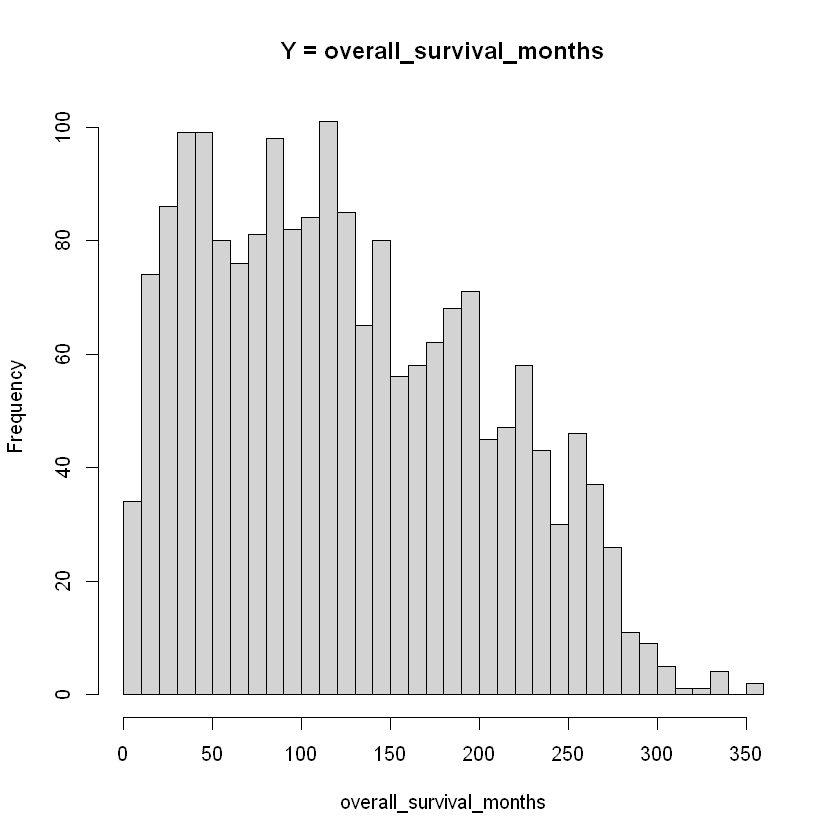

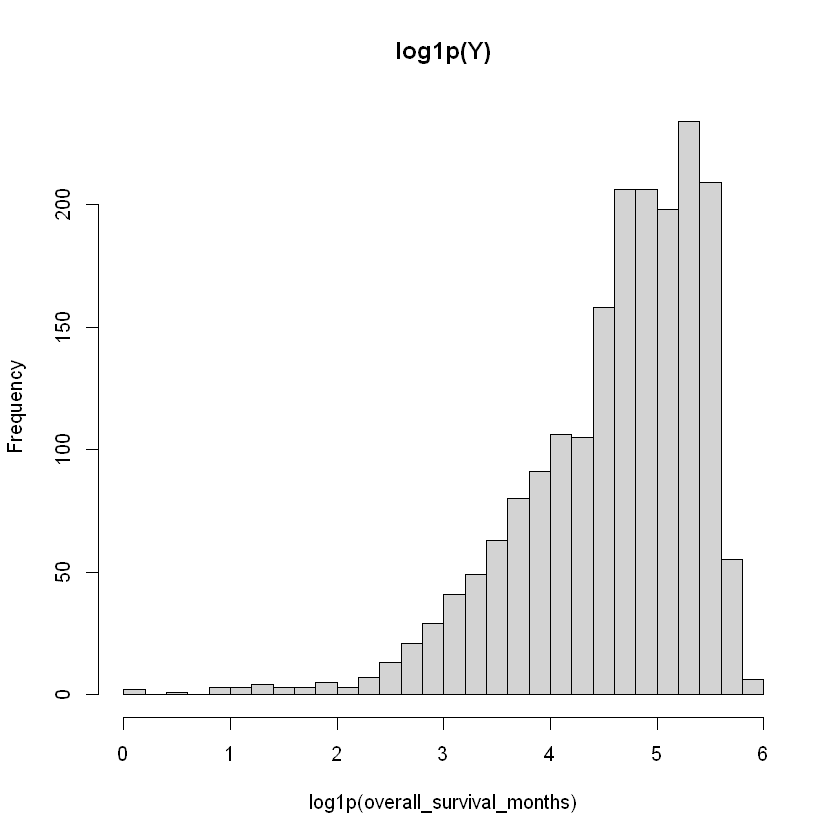

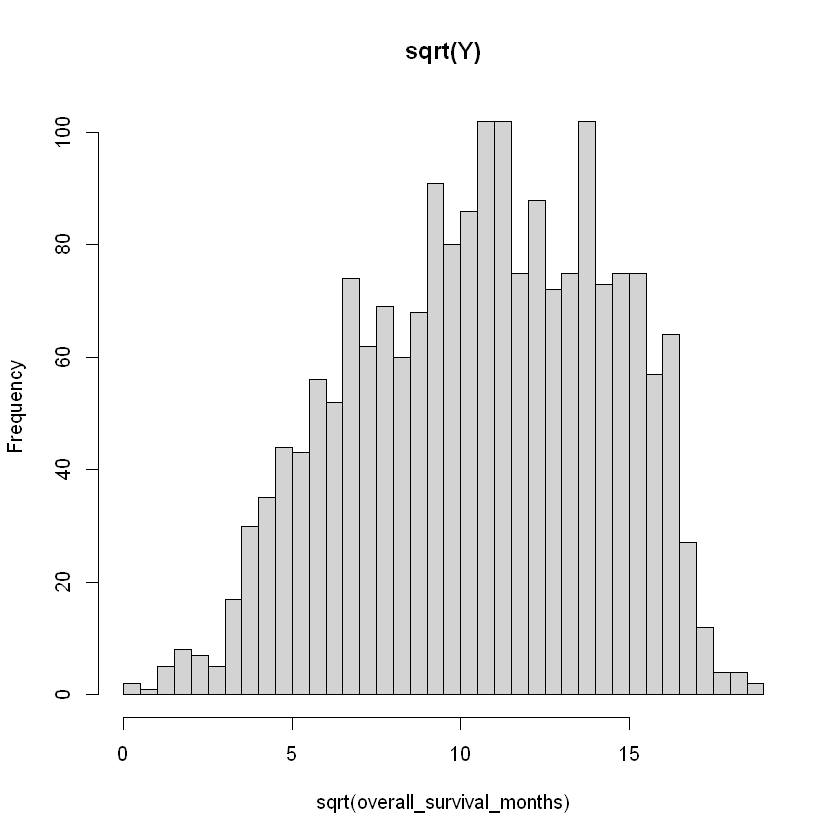

In [6]:
# Check target skew
round(skewness(raw_df$overall_survival_months, na.rm = TRUE), 3)

# Raw distribution of `overall_survival_months`
hist(raw_df$overall_survival_months,
     breaks = 40,
     main = "Y = overall_survival_months",
     xlab = "overall_survival_months")

# Log transformation
hist(log1p(raw_df$overall_survival_months),
     breaks = 40,
     main = "log1p(Y)",
     xlab = "log1p(overall_survival_months)")

# Square root transformation
hist(sqrt(raw_df$overall_survival_months),
     breaks = 40,
     main = "sqrt(Y)",
     xlab = "sqrt(overall_survival_months)")

#### Distribution note
- Cox doesn't assume normality/parametric form. So distribution transformation won't benefit model.
- Instead: 
    - Event balance (overall_survival)
    - Temporal order (overall_survival_months)
    - Predictor variance
    - Highly correlated predictors

In [7]:
# Event distribution (alive or dead) [target variable to combine with time variable for survival analysis]
table(raw_df$overall_survival, useNA = "ifany")


   0    1 
1103  801 

# **Split high-dimensional dataset for easier pre-process**

In [8]:
clinical_vars <- raw_df %>%
  select(age_at_diagnosis:(brca1)) %>% 
  select(-brca1)

gene_vars <- raw_df %>%
  select(brca1:pik3ca_mut) %>%
  select(-pik3ca_mut)

mutation_vars <- raw_df %>%
  select(ends_with("_mut"))

In [9]:
head(clinical_vars)
head(gene_vars)
head(mutation_vars)

,age_at_diagnosis,type_of_breast_surgery,cancer_type,cancer_type_detailed,cellularity,chemotherapy,pam50_._claudin.low_subtype,cohort,er_status_measured_by_ihc,er_status,⋯,nottingham_prognostic_index,oncotree_code,overall_survival_months,overall_survival,pr_status,radio_therapy,X3.gene_classifier_subtype,tumor_size,tumor_stage,death_from_cancer
,<dbl>,<chr>,<chr>,<chr>,<chr>,<int>,<chr>,<dbl>,<chr>,<chr>,⋯,<dbl>,<chr>,<dbl>,<int>,<chr>,<int>,<chr>,<dbl>,<dbl>,<chr>
1,75.65,MASTECTOMY,Breast Cancer,Breast Invasive Ductal Carcinoma,,0,claudin-low,1,Positve,Positive,⋯,6.044,IDC,140.50000,1,Negative,1,ER-/HER2-,22,2,Living
2,43.19,BREAST CONSERVING,Breast Cancer,Breast Invasive Ductal Carcinoma,High,0,LumA,1,Positve,Positive,⋯,4.020,IDC,84.63333,1,Positive,1,ER+/HER2- High Prolif,10,1,Living
3,48.87,MASTECTOMY,Breast Cancer,Breast Invasive Ductal Carcinoma,High,1,LumB,1,Positve,Positive,⋯,4.030,IDC,163.70000,0,Positive,0,,15,2,Died of Disease
4,47.68,MASTECTOMY,Breast Cancer,Breast Mixed Ductal and Lobular Carcinoma,Moderate,1,LumB,1,Positve,Positive,⋯,4.050,MDLC,164.93333,1,Positive,1,,25,2,Living
5,76.97,MASTECTOMY,Breast Cancer,Breast Mixed Ductal and Lobular Carcinoma,High,1,LumB,1,Positve,Positive,⋯,6.080,MDLC,41.36667,0,Positive,1,ER+/HER2- High Prolif,40,2,Died of Disease
6,78.77,MASTECTOMY,Breast Cancer,Breast Invasive Ductal Carcinoma,Moderate,0,LumB,1,Positve,Positive,⋯,4.062,IDC,7.80000,0,Positive,1,ER+/HER2- High Prolif,31,4,Died of Disease


,brca1,brca2,palb2,pten,tp53,atm,cdh1,chek2,nbn,nf1,⋯,srd5a1,srd5a2,srd5a3,st7,star,tnk2,tulp4,ugt2b15,ugt2b17,ugt2b7
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,-1.3990,-0.5738,-1.6217,1.4524,0.3504,1.1517,0.0348,0.1266,-0.8361,-0.8578,⋯,-1.1877,-0.0194,-1.6345,-0.2142,-0.5698,-1.1741,-1.4779,-0.5954,-0.8847,-0.3354
2,-1.3800,0.2777,-1.2154,0.5296,-0.0136,-0.2659,1.3594,0.7961,0.5419,-2.6059,⋯,-0.4412,0.4534,0.4068,0.7634,0.0231,0.9121,-0.9538,-0.2264,0.5398,-0.8920
3,0.0670,-0.8426,0.2114,-0.3326,0.5141,-0.0803,1.1398,0.4187,-0.4030,-1.1305,⋯,-0.5381,0.0668,0.8344,1.7227,0.4024,-3.7172,-1.5538,1.3701,-0.1078,0.3655
4,0.6744,-0.5428,-1.6592,0.6369,1.6708,-0.8880,1.2491,-1.1889,-0.4174,-0.6165,⋯,-0.5630,-0.7078,0.8228,0.6819,-0.1948,-2.3286,-0.9924,-0.3154,0.2320,-0.4828
5,1.2932,-0.9039,-0.7219,0.2168,0.3484,0.3897,0.9131,0.9356,0.7675,-0.2940,⋯,-0.5845,-0.3544,-1.0150,2.2961,0.1817,-0.1572,0.0427,5.0048,3.8476,1.3223
6,-0.4341,0.6931,0.6909,1.0840,-1.9371,0.9252,1.1520,0.7951,-0.9677,-0.7750,⋯,-0.3910,0.0395,0.8191,0.1977,-0.2302,-0.5092,-0.3021,0.9357,-0.4217,0.5340


,pik3ca_mut,tp53_mut,muc16_mut,ahnak2_mut,kmt2c_mut,syne1_mut,gata3_mut,map3k1_mut,ahnak_mut,dnah11_mut,⋯,mtap_mut,ppp2cb_mut,smarcd1_mut,nras_mut,ndfip1_mut,hras_mut,prps2_mut,smarcb1_mut,stmn2_mut,siah1_mut
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,⋯,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
1,0,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
2,0,H178P,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
3,H1047R,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
4,E542K,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
5,0,S241F,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
6,H1047R,P67Qfs*56,0,0,0,0,A318T,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0


In [10]:
# Predictor variable counts by type
data.frame(
  group = c("Clinical", "Gene expression", "Mutation", "Total"),
  count = c(ncol(clinical_vars), 
            ncol(gene_vars), 
            ncol(mutation_vars), 
            sum(ncol(clinical_vars), ncol(gene_vars), ncol(mutation_vars))
            )
)

group,count
<chr>,<int>
Clinical,30
Gene expression,489
Mutation,173
Total,692


### All 692 columns broken up into respective sub-dataset for easier pre-processing differing variable types.
- clinical_vars
- gene_vars
- mutation_vars

# **Pre-processing `clinical` predictor variables**

In [11]:
# Quick glance at shape, types, and classes 
str(clinical_vars)

'data.frame':	1904 obs. of  30 variables:
 $ age_at_diagnosis              : num  75.7 43.2 48.9 47.7 77 ...
 $ type_of_breast_surgery        : chr  "MASTECTOMY" "BREAST CONSERVING" "MASTECTOMY" "MASTECTOMY" ...
 $ cancer_type                   : chr  "Breast Cancer" "Breast Cancer" "Breast Cancer" "Breast Cancer" ...
 $ cancer_type_detailed          : chr  "Breast Invasive Ductal Carcinoma" "Breast Invasive Ductal Carcinoma" "Breast Invasive Ductal Carcinoma" "Breast Mixed Ductal and Lobular Carcinoma" ...
 $ cellularity                   : chr  "" "High" "High" "Moderate" ...
 $ chemotherapy                  : int  0 0 1 1 1 0 1 0 0 0 ...
 $ pam50_._claudin.low_subtype   : chr  "claudin-low" "LumA" "LumB" "LumB" ...
 $ cohort                        : num  1 1 1 1 1 1 1 1 1 1 ...
 $ er_status_measured_by_ihc     : chr  "Positve" "Positve" "Positve" "Positve" ...
 $ er_status                     : chr  "Positive" "Positive" "Positive" "Positive" ...
 $ neoplasm_histologic_grade     : n

In [12]:
# Check missingness in clinical variables
clinical_missing <- data.frame(
  variable = names(clinical_vars),
  missing = colSums(is.na(clinical_vars)),
  missing_pct = round(colMeans(is.na(clinical_vars)) * 100, 3)
)

# View missing data variables
clinical_missing <- clinical_missing[clinical_missing$missing > 0, ]
clinical_missing

,variable,missing,missing_pct
,<chr>,<dbl>,<dbl>
neoplasm_histologic_grade,neoplasm_histologic_grade,72,3.782
mutation_count,mutation_count,45,2.363
tumor_size,tumor_size,20,1.050
tumor_stage,tumor_stage,501,26.313


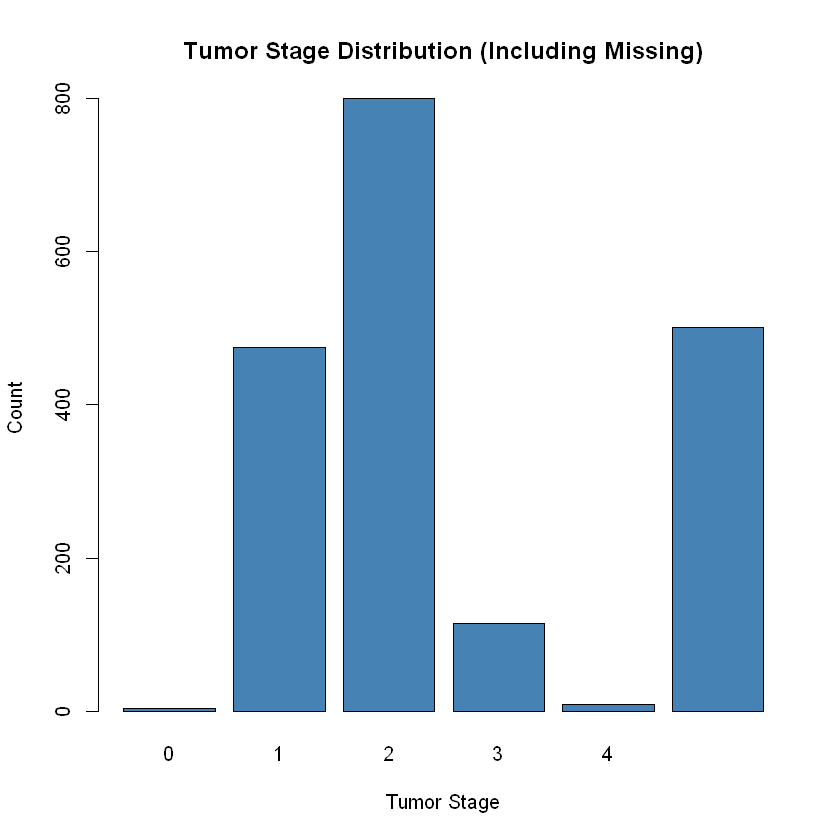

In [13]:
# Missingness distribution for `tumor_stage`

# Table for distribution plot
stage_counts <- table(addNA(clinical_vars$tumor_stage))

# Visual distribution of tumor stage
barplot(
  stage_counts,
  main = "Tumor Stage Distribution (Including Missing)",
  xlab = "Tumor Stage",
  ylab = "Count",
  col = "steelblue"
)

In [14]:
# View categorical variables in clinical data
cat_vars <- clinical_vars %>%
  select(where(~ is.character(.) | is.factor(.)))

names(cat_vars)

[1] "type_of_breast_surgery"         "cancer_type"                   
 [3] "cancer_type_detailed"           "cellularity"                   
 [5] "pam50_._claudin.low_subtype"    "er_status_measured_by_ihc"     
 [7] "er_status"                      "her2_status_measured_by_snp6"  
 [9] "her2_status"                    "tumor_other_histologic_subtype"
[11] "inferred_menopausal_state"      "integrative_cluster"           
[13] "primary_tumor_laterality"       "oncotree_code"                 
[15] "pr_status"                      "X3.gene_classifier_subtype"    
[17] "death_from_cancer"

In [15]:
# Transform categorical variables for modeling
clinical_vars <- clinical_vars %>%
  mutate(across(where(is.character), as.factor))

# Transform numeric categorical variables as factor
clinical_vars <- clinical_vars %>%
  mutate(
    chemotherapy = as.factor(chemotherapy),
    hormone_therapy = as.factor(hormone_therapy),
    radio_therapy = as.factor(radio_therapy),
    tumor_stage = as.factor(tumor_stage),
    cohort = as.factor(cohort)
  )

In [16]:
# Check variable types after transformation
sapply(clinical_vars, class)

age_at_diagnosis         type_of_breast_surgery 
                     "numeric"                       "factor" 
                   cancer_type           cancer_type_detailed 
                      "factor"                       "factor" 
                   cellularity                   chemotherapy 
                      "factor"                       "factor" 
   pam50_._claudin.low_subtype                         cohort 
                      "factor"                       "factor" 
     er_status_measured_by_ihc                      er_status 
                      "factor"                       "factor" 
     neoplasm_histologic_grade   her2_status_measured_by_snp6 
                     "numeric"                       "factor" 
                   her2_status tumor_other_histologic_subtype 
                      "factor"                       "factor" 
               hormone_therapy      inferred_menopausal_state 
                      "factor"                       "factor" 
           integrative_cluster       primary_tumor_laterality 
                      "factor"                       "factor" 
 lymph_nodes_examined_positive                 mutation_count 
                     "numeric"                      "numeric" 
   nottingham_prognostic_index                  oncotree_code 
                     "numeric"                       "factor" 
       overall_survival_months               overall_survival 
                     "numeric"                      "integer" 
                     pr_status                  radio_therapy 
                      "factor"                       "factor" 
    X3.gene_classifier_subtype                     tumor_size 
                      "factor"                      "numeric" 
                   tumor_stage              death_from_cancer 
                      "factor"                       "factor"

In [17]:
# Count of categorical variables after transformation
sum(sapply(clinical_vars, is.factor))

[1] 22

In [18]:
# Distribution of categorical variables
for(x in names(cat_vars)){
  print(x)
  print(table(cat_vars[[x]]))
}

[1] "type_of_breast_surgery"

                  BREAST CONSERVING        MASTECTOMY 
               22               755              1127 
[1] "cancer_type"

 Breast Cancer Breast Sarcoma 
          1903              1 
[1] "cancer_type_detailed"

                                          
                                       15 
                                   Breast 
                                       17 
         Breast Invasive Ductal Carcinoma 
                                     1500 
        Breast Invasive Lobular Carcinoma 
                                      142 
 Breast Invasive Mixed Mucinous Carcinoma 
                                       22 
Breast Mixed Ductal and Lobular Carcinoma 
                                      207 
                Metaplastic Breast Cancer 
                                        1 
[1] "cellularity"

             High      Low Moderate 
      54      939      200      711 
[1] "pam50_._claudin.low_subtype"

      Basal claudin-l

## Decisions
- Impute 26% missingness
- Remove `cancer_type` 'Breast Sarcoma' due to sample size of **1** in with 2nd class at ~1900

## Imputation

In [19]:
# Imputation is random sampling
set.seed(2026) 

# Re-define `tumor_stage` as character for imputation
tumor_stage_chr <- as.character(clinical_vars$tumor_stage)

# Pre-imputation distribution of `tumor_stage`
stage_dist <- prop.table(table(tumor_stage_chr, useNA = "no"))
cat("Observed tumor_stage distribution (pre-impute):\n")
print(stage_dist)

# Identify indices of missing `tumor_stage` values
missing_idx <- which(is.na(tumor_stage_chr))

# Impute missing `tumor_stage` values based on observed distribution
tumor_stage_chr[missing_idx] <- sample(
  x = names(stage_dist),
  size = length(missing_idx),
  replace = TRUE,
  prob = as.numeric(stage_dist)
)

# Convert back to factor
clinical_vars$tumor_stage <- factor(tumor_stage_chr)

# Post-imputation distribution of `tumor_stage`
cat("Observed tumor_stage distribution (post-impute):\n")
print(prop.table(table(clinical_vars$tumor_stage, useNA = "ifany")))
cat("\n","Number of missing values after imputation: ", sum(is.na(clinical_vars$tumor_stage)))

Observed tumor_stage distribution (pre-impute):
tumor_stage_chr
          0           1           2           3           4 
0.002851033 0.338560228 0.570206700 0.081967213 0.006414825 
Observed tumor_stage distribution (post-impute):

          0           1           2           3           4 
0.002100840 0.339810924 0.573004202 0.079306723 0.005777311 

 Number of missing values after imputation:  0

# **Pre-processing gene predictor variables**

In [20]:
# Quick glance at shape, types, and classes
str(gene_vars)

'data.frame':	1904 obs. of  489 variables:
 $ brca1    : num  -1.399 -1.38 0.067 0.674 1.293 ...
 $ brca2    : num  -0.574 0.278 -0.843 -0.543 -0.904 ...
 $ palb2    : num  -1.622 -1.215 0.211 -1.659 -0.722 ...
 $ pten     : num  1.452 0.53 -0.333 0.637 0.217 ...
 $ tp53     : num  0.3504 -0.0136 0.5141 1.6708 0.3484 ...
 $ atm      : num  1.1517 -0.2659 -0.0803 -0.888 0.3897 ...
 $ cdh1     : num  0.0348 1.3594 1.1398 1.2491 0.9131 ...
 $ chek2    : num  0.127 0.796 0.419 -1.189 0.936 ...
 $ nbn      : num  -0.836 0.542 -0.403 -0.417 0.767 ...
 $ nf1      : num  -0.858 -2.606 -1.131 -0.617 -0.294 ...
 $ stk11    : num  -0.429 0.512 0.236 1.008 -0.296 ...
 $ bard1    : num  -1.12 0.439 -0.172 -0.401 0.632 ...
 $ mlh1     : num  -0.484 1.227 -1.791 -1.391 -0.358 ...
 $ msh2     : num  -0.748 0.761 3.095 4.88 0.303 ...
 $ msh6     : num  -1.666 0.1821 0.6608 0.0615 0.8747 ...
 $ pms2     : num  -0.125 1.01 2.613 2.941 0.632 ...
 $ epcam    : num  -0.372 0.56 2.555 4.116 0.335 ...
 $ rad5

In [21]:
# Check if all gene expression variables are numeric
numeric <- all(sapply(gene_vars, is.numeric))
numeric

[1] TRUE

In [22]:
# Check missingness in gene expression variables
gene_missing <- data.frame(
  variable = names(gene_vars),
  missing = colSums(is.na(gene_vars)),
  missing_pct = round(colMeans(is.na(gene_vars)) * 100, 3)
)

# View missing data variables
gene_missing <- gene_missing[gene_missing$missing > 0, ]
gene_missing

variable,missing,missing_pct
<chr>,<dbl>,<dbl>


In [23]:
# Looking at mean and variance of gene expression variables
summary(gene_vars)

     brca1                brca2                palb2           
 Min.   :-2.4444000   Min.   :-2.7835000   Min.   :-4.3846000  
 1st Qu.:-0.7198500   1st Qu.:-0.6994750   1st Qu.:-0.6798250  
 Median :-0.1244500   Median :-0.0582000   Median :-0.0221000  
 Mean   :-0.0000006   Mean   :-0.0000004   Mean   : 0.0000004  
 3rd Qu.: 0.5532250   3rd Qu.: 0.6290000   3rd Qu.: 0.6400000  
 Max.   : 4.5542000   Max.   : 3.7379000   Max.   : 4.6150000  
      pten                 tp53                 atm            
 Min.   :-5.9328000   Min.   :-2.4812000   Min.   :-3.1705000  
 1st Qu.:-0.5586500   1st Qu.:-0.6661500   1st Qu.:-0.6602250  
 Median : 0.1098500   Median :-0.0301000   Median :-0.0042000  
 Mean   :-0.0000009   Mean   : 0.0000006   Mean   :-0.0000002  
 3rd Qu.: 0.6426250   3rd Qu.: 0.6447500   3rd Qu.: 0.6901500  
 Max.   : 3.2541000   Max.   : 4.2898000   Max.   : 3.8242000  
      cdh1                chek2              nbn            
 Min.   :-3.3237000   Min.   :-2.6887   Min

In [24]:
# Scale gene expression variables for modeling
gene_vars_scaled <- scale(gene_vars)
summary(gene_vars_scaled)

     brca1             brca2              palb2               pten        
 Min.   :-2.4438   Min.   :-2.78277   Min.   :-4.38345   Min.   :-5.9312  
 1st Qu.:-0.7197   1st Qu.:-0.69929   1st Qu.:-0.67965   1st Qu.:-0.5585  
 Median :-0.1244   Median :-0.05818   Median :-0.02209   Median : 0.1098  
 Mean   : 0.0000   Mean   : 0.00000   Mean   : 0.00000   Mean   : 0.0000  
 3rd Qu.: 0.5531   3rd Qu.: 0.62884   3rd Qu.: 0.63983   3rd Qu.: 0.6425  
 Max.   : 4.5530   Max.   : 3.73692   Max.   : 4.61379   Max.   : 3.2532  
      tp53               atm                 cdh1             chek2        
 Min.   :-2.48055   Min.   :-3.169668   Min.   :-3.3228   Min.   :-2.6880  
 1st Qu.:-0.66598   1st Qu.:-0.660052   1st Qu.:-0.4585   1st Qu.:-0.7384  
 Median :-0.03009   Median :-0.004199   Median : 0.1155   Median :-0.1311  
 Mean   : 0.00000   Mean   : 0.000000   Mean   : 0.0000   Mean   : 0.0000  
 3rd Qu.: 0.64458   3rd Qu.: 0.689969   3rd Qu.: 0.6496   3rd Qu.: 0.5430  
 Max.   : 4.28867  

In [25]:
# Verify dimensions of scaled gene variables to ensure no data loss during scaling
dim(gene_vars_scaled)

[1] 1904  489

# **Pre-processing mutation predictor variables**

In [26]:
# Unique values in mutation variables
table_values <- unique(unlist(mutation_vars))
table_values

n_distinct(table_values)

[1] "0"                                                              
   [2] "H1047R"                                                         
   [3] "E542K"                                                          
   [4] "Q546H G1049R"                                                   
   [5] "E545K"                                                          
   [6] "N345K E81K"                                                     
   [7] "H1047L E726K"                                                   
   [8] "H1047L"                                                         
   [9] "E545Q"                                                          
  [10] "N345K"                                                          
  [11] "L452Kfs*4 E453Dfs*7"                                            
  [12] "N345K N1044K"                                                   
  [13] "E365K C420R"                                                    
  [14] "E545K H1047R"                                                   
  [15] "E542K E726K"                                                    
  [16] "E453_L455del"                                                   
  [17] "G451_D454del"                                                   
  [18] "E110del"                                                        
  [19] "Q546K"                                                          
  [20] "H1047R E453K"                                                   
  [21] "R88Q"                                                           
  [22] "H1047R P104L"                                                   
  [23] "H1047R E726K"                                                   
  [24] "M1043V"                                                         
  [25] "Q546P"                                                          
  [26] "N1068Kfs*5"                                                     
  [27] "H1047R R108H"                                                   
  [28] "K111E"                                                          
  [29] "H1047R G118D"                                                   
  [30] "H1047R H1048R"                                                  
  [31] "E545G"                                                          
  [32] "E542K N345K"                                                    
  [33] "E545K G320A"                                                    
  [34] "E545K S509Y"                                                    
  [35] "E418K"                                                          
  [36] "E545K G914R"                                                    
  [37] "H1047R L10_P17del"                                              
  [38] "C420R"                                                          
  [39] "P449S"                                                          
  [40] "E545K E726K"                                                    
  [41] "H1047R E81K"                                                    
  [42] "Q546R"                                                          
  [43] "H1047R D1029H H1048R"                                           
  [44] "E545K M1043V"                                                   
  [45] "P449T"                                                          
  [46] "V105del K148N"                                                  
  [47] "A1066Cfs*7"                                                     
  [48] "H1047R T727K"                                                   
  [49] "E545A"                                                          
  [50] "H1047R E80K"                                                    
  [51] "E726K"                                                          
  [52] "H1047L E385K"                                                   
  [53] "H1047R K111E"                                                   
  [54] "E542K T727K"                                                    
  [55] "M1043I"                                              

[1] 7668

In [27]:
# Check missingness in mutation variables
mutation_missing <- data.frame(
  variable = names(mutation_vars),
  missing = colSums(is.na(mutation_vars)),
  missing_pct = round(colMeans(is.na(mutation_vars)) * 100, 3)
)

mutation_missing <- mutation_missing[mutation_missing$missing > 0, ]
mutation_missing

variable,missing,missing_pct
<chr>,<dbl>,<dbl>


In [28]:
# Transform mutation variables to binary (0 = no mutation, 1 = mutation)
mutation_vars_bin <- mutation_vars %>%
  mutate(across(
    everything(),
    ~ {
      x <- as.character(.)
      x <- trimws(x)
      ifelse(x == "0" | is.na(x) | x == "", 0, 1)
    }
  )) %>%
  mutate(across(everything(), as.integer))

In [29]:
# Check unique values after transformation (and distribution)
table(unlist(mutation_vars_bin), useNA = "ifany")


     0      1 
319653   9739 

# **Combining back into single df**

In [30]:
# Dimensions need to be consistent across all datasets to merge
nrow(clinical_vars)
nrow(gene_vars_scaled)
nrow(mutation_vars_bin)

[1] 1904

[1] 1904

[1] 1904

In [31]:
# Only processed rows
keep_rows <- complete.cases(
  clinical_vars,
  gene_vars_scaled,
  mutation_vars_bin
)

# Row removals
keep_rows <- keep_rows & clinical_vars$cancer_type != "Breast Sarcoma"

# applying row filter 
clinical_vars      <- clinical_vars[keep_rows, ]
gene_vars_scaled   <- gene_vars_scaled[keep_rows, ]
mutation_vars_bin  <- mutation_vars_bin[keep_rows, ]

# target variables 
time_var  <- clinical_vars$overall_survival_months
event_var <- clinical_vars$overall_survival

# Column removals (not useful or harmful to model)
clinical_vars <- clinical_vars %>% 
  select(
    -any_of(c(
      "death_from_cancer", # outcome leak
      "cohort", # groups of people
      "patient_id", # identifier
      "overall_survival", # outcome leak
      "overall_survival_months", # outcome leak
      "nottingham_prognostic_index" # outcome leak - clinical tool used to predict survival 
    ))
  )

# Re-combine
model_df <- data.frame(clinical_vars, gene_vars_scaled, mutation_vars_bin)

In [32]:
# Final checks

# Checking removal of "Breast Sarcoma" cancer type
table(clinical_vars$cancer_type)

# Number of removed rows due to missingness or intentional removal
sum(!keep_rows)

# Final dimensions of datasets after filtering
dim(model_df)


 Breast Cancer Breast Sarcoma 
          1770              0 

[1] 134

[1] 1770  687

# **Part 1: Model Selection Methods**

In [33]:
# Create survival object for modeling
surv_object <- Surv(time_var, event_var)
surv_object

   [1]  84.6333333  163.7000000+ 164.9333333   41.3666667+   7.8000000+
   [6] 164.3333333   99.5333333+  36.5666667+  36.2666667+ 132.0333333+
  [11] 163.5333333   14.1333333+ 160.3000000   62.8666667  140.8666667 
  [16] 153.9666667  157.4333333  103.1333333   28.5000000+  69.5000000 
  [21]  86.0666667+ 153.2000000   49.7666667+  98.7000000    8.0666667+
  [26] 148.0333333  140.7666667+  85.3333333  158.0333333   42.7000000+
  [31] 112.4000000+ 127.1000000   39.1666667+  13.4000000   66.7333333+
  [36] 122.2666667    2.4000000   95.8666667+  29.0666667+ 152.2000000 
  [41] 138.9000000  114.2333333+ 118.2000000    1.2666667  132.0666667 
  [46] 137.8000000   66.6333333+ 151.0000000   12.9333333+  88.2000000 
  [51] 150.5666667  109.2000000  147.9333333   54.3333333+ 152.0666667+
  [56] 147.6666667   51.7666667+   1.7666667   51.7000000+ 111.2000000 
  [61]  49.2333333+  63.0333333  114.7666667   59.8000000  114.7666667 
  [66]  55.7666667   98.1000000+  10.8333333   47.6333333+ 104.4

In [34]:
# check numerical correlations
num_vars <- clinical_vars %>%
  select(where(is.numeric))

cor(num_vars)

,age_at_diagnosis,neoplasm_histologic_grade,lymph_nodes_examined_positive,mutation_count,tumor_size
age_at_diagnosis,1.000000000,-0.12016282,-0.006969268,0.004009277,0.04446875
neoplasm_histologic_grade,-0.120162824,1.00000000,0.141240430,0.056672970,0.13163772
lymph_nodes_examined_positive,-0.006969268,0.14124043,1.000000000,-0.043243941,0.26481467
mutation_count,0.004009277,0.05667297,-0.043243941,1.000000000,0.01911570
tumor_size,0.044468750,0.13163772,0.264814674,0.019115699,1.00000000


In [35]:
# Reduce linear dependencies and multicollinearity by removing `cancer_type_detailed` and `oncotree_code` (highly correlated with `cancer_type`)
clinical_subset_df <- clinical_vars |>
  subset(select = -c(cancer_type_detailed, oncotree_code))

## Best Subset Selection

In [36]:
# Forward selection
reg_fwd <- regsubsets(
  time_var ~ .,
  data = clinical_subset_df,
  nvmax = ncol(clinical_subset_df) - 1,
  method = "forward"
)

reg_fwd_summary <- summary(reg_fwd)

which.max(reg_fwd_summary$adjr2)
which.min(reg_fwd_summary$cp)
which.min(reg_fwd_summary$bic)

reg_fwd_var <- names(coef(reg_fwd, id = 10))[-1]
reg_fwd_var

Warning message in leaps.setup(x, y, wt = wt, nbest = nbest, nvmax = nvmax, force.in = force.in, :
"3  linear dependencies found"


Reordering variables and trying again:


[1] 23

[1] 22

[1] 10

[1] "age_at_diagnosis"                      
 [2] "pam50_._claudin.low_subtypeclaudin-low"
 [3] "pam50_._claudin.low_subtypeLumB"       
 [4] "tumor_other_histologic_subtypeMixed"   
 [5] "integrative_cluster10"                 
 [6] "integrative_cluster2"                  
 [7] "integrative_cluster7"                  
 [8] "pr_statusPositive"                     
 [9] "X3.gene_classifier_subtypeER-/HER2-"   
[10] "tumor_stage2"

In [37]:
# Backward selection
reg_bwd <- regsubsets(
  time_var ~ .,
  data = clinical_subset_df,
  nvmax = ncol(clinical_subset_df) - 1,
  method = "backward"
)

reg_bwd_summary <- summary(reg_bwd)

which.max(reg_bwd_summary$adjr2)
which.min(reg_bwd_summary$cp)
which.min(reg_bwd_summary$bic)

reg_bwd_var <- names(coef(reg_bwd, id = 10))[-1]
reg_bwd_var

Warning message in leaps.setup(x, y, wt = wt, nbest = nbest, nvmax = nvmax, force.in = force.in, :
"3  linear dependencies found"


Reordering variables and trying again:


[1] 23

[1] 23

[1] 10

[1] "age_at_diagnosis"                      
 [2] "pam50_._claudin.low_subtypeclaudin-low"
 [3] "pam50_._claudin.low_subtypeLumB"       
 [4] "integrative_cluster10"                 
 [5] "integrative_cluster2"                  
 [6] "integrative_cluster7"                  
 [7] "lymph_nodes_examined_positive"         
 [8] "mutation_count"                        
 [9] "pr_statusPositive"                     
[10] "tumor_stage2"

In [38]:
# Sequential replacement selection
reg_seqrep <- regsubsets(
  time_var ~ .,
  data = clinical_subset_df,
  nvmax = ncol(clinical_subset_df) - 1,
  method = "seqrep"
)

reg_seqrep_summary <- summary(reg_seqrep)

which.max(reg_seqrep_summary$adjr2)
which.min(reg_seqrep_summary$cp)
which.min(reg_seqrep_summary$bic)

reg_seqrep_var <- names(coef(reg_seqrep, id = 11))[-1]
reg_seqrep_var

Warning message in leaps.setup(x, y, wt = wt, nbest = nbest, nvmax = nvmax, force.in = force.in, :
"3  linear dependencies found"


Reordering variables and trying again:


[1] 22

[1] 19

[1] 11

[1] "age_at_diagnosis"                       
 [2] "type_of_breast_surgeryBREAST CONSERVING"
 [3] "type_of_breast_surgeryMASTECTOMY"       
 [4] "pam50_._claudin.low_subtypeclaudin-low" 
 [5] "pam50_._claudin.low_subtypeLumB"        
 [6] "integrative_cluster10"                  
 [7] "integrative_cluster2"                   
 [8] "integrative_cluster7"                   
 [9] "pr_statusPositive"                      
[10] "X3.gene_classifier_subtypeER-/HER2-"    
[11] "tumor_stage2"

In [39]:
# Cox subset model with variables from sequential replacement selection
cox_subset <- coxph(
  surv_object ~ age_at_diagnosis +
    type_of_breast_surgery +
    pam50_._claudin.low_subtype +
    integrative_cluster +
    pr_status +
    X3.gene_classifier_subtype +
    tumor_stage,
  data = clinical_subset_df
)

summary(cox_subset)

Call:
coxph(formula = surv_object ~ age_at_diagnosis + type_of_breast_surgery + 
    pam50_._claudin.low_subtype + integrative_cluster + pr_status + 
    X3.gene_classifier_subtype + tumor_stage, data = clinical_subset_df)

  n= 1770, number of events= 744 

                                                     coef exp(coef)  se(coef)
age_at_diagnosis                                -0.005148  0.994865  0.003396
type_of_breast_surgeryBREAST CONSERVING         -1.388907  0.249348  0.419586
type_of_breast_surgeryMASTECTOMY                -1.689146  0.184677  0.420257
pam50_._claudin.low_subtypeclaudin-low          -0.020137  0.980065  0.162281
pam50_._claudin.low_subtypeHer2                 -0.459110  0.631846  0.215000
pam50_._claudin.low_subtypeLumA                 -0.152357  0.858682  0.201506
pam50_._claudin.low_subtypeLumB                 -0.057453  0.944166  0.209147
pam50_._claudin.low_subtypeNC                   -0.562155  0.569979  1.026601
pam50_._claudin.low_subtypeNormal      

In [40]:
# Create table of hazard ratios and significant p-values for interpretation
interpret_table <- data.frame(
  Hazard_Ratio = summary(cox_subset)$coefficients[,2],
  p_value = summary(cox_subset)$coefficients[,5]
)

interpret_table <- interpret_table[!is.na(interpret_table$Hazard_Ratio), ]
interpret_table <- interpret_table[interpret_table$p_value < 0.05, ]

interpret_table %>%
  arrange(desc(Hazard_Ratio))

,Hazard_Ratio,p_value
,<dbl>,<dbl>
X3.gene_classifier_subtypeHER2+,2.2271668,1.960583e-03
X3.gene_classifier_subtypeER+/HER2- Low Prolif,1.9233914,3.038453e-05
X3.gene_classifier_subtypeER+/HER2- High Prolif,1.6304197,3.232592e-03
X3.gene_classifier_subtypeER-/HER2-,1.4673810,4.189207e-02
pam50_._claudin.low_subtypeHer2,0.6318460,3.272879e-02
integrative_cluster6,0.5658617,2.018481e-02
type_of_breast_surgeryBREAST CONSERVING,0.2493478,9.323504e-04
type_of_breast_surgeryMASTECTOMY,0.1846771,5.836728e-05


## Selected model key predictors (Sequential Replacement hazard ratio, and p-value)
> - Hazard ratio answers "how large of an effect".
> - 1 = no effect , > 1 = increased risk , < 1 = decreased risk.
#### Strongest  predictors:
- X3.gene_classifier_subtypeER+/HER2- High Prolif  1.636049       0.00300 ** 
- X3.gene_classifier_subtypeER+/HER2- Low Prolif   1.918710       3.42e-05 ***
- X3.gene_classifier_subtypeHER2+                  2.261060       0.00156 **
- type_of_breast_surgeryBREAST CONSERVING          0.250767       0.00098
- type_of_breast_surgeryMASTECTOMY                 0.183899       5.58e-05
#### Moderate Predictors:
- pam50_._claudin.low_subtypeHer2                  0.626463       0.03021
- integrative_cluster6                             0.559959       0.01816
#### Weak Predictors:
- integrative_cluster8                             0.705930       0.05970
- X3.gene_classifier_subtypeER-/HER2-              1.440352       0.05255
#### Insignificant Predictors:
- age_at_diagnosis                                 0.994612       0.11229 
- pr_status                                        0.916379       0.37406
- most integrative clusters                        0.8 to > 1.0   0.1 to 0.5
- tumor_stage                                      0.4 to 0.6     0.1 to 0.4

### Summary:
- Strongest predictors are related to the gene classification for breast cancer. It can be observed with p-values lower than 0.05. This infers that mortality rate is tied closely with these predictors. 

- Moderate predictors `pam claudi` and `integrative cluster 6` both have p-values slightly below 0.05 but not as low as the strongest predictors, this indicates that they are a contributing factor to mortality but are not the main cause of it. 

- Weakest predictors `integrative cluster 8` and `gene classifier subtype Er` both have p-values just above 0.05 indicating that they may contribute to mortality but will require more data to confirm. To our surprise, variables `age` and `tumor_stage` do not contribute to the cause of mortality as their p-values exceed 0.1 indicating that these factors are irrelevant when determing survival.

## Stepwise Selection

In [41]:
set.seed(2026)

# Full Cox model with all clinical variables
cox_full <- coxph(
  surv_object ~ .,
  data = clinical_subset_df
)

# Model selection using AIC and BIC
cox_aic <- step(cox_full, direction = "both", trace = 0)
cox_bic <- step(cox_full, direction = "both", k = log(nrow(clinical_subset_df)), trace = 0)

# summaries
summary(cox_aic)
summary(cox_bic)

Call:
coxph(formula = surv_object ~ type_of_breast_surgery + chemotherapy + 
    er_status + neoplasm_histologic_grade + her2_status_measured_by_snp6 + 
    tumor_other_histologic_subtype + hormone_therapy + primary_tumor_laterality + 
    lymph_nodes_examined_positive + mutation_count + X3.gene_classifier_subtype, 
    data = clinical_subset_df)

  n= 1770, number of events= 744 

                                                      coef exp(coef) se(coef)
type_of_breast_surgeryBREAST CONSERVING           -1.07321   0.34191  0.44805
type_of_breast_surgeryMASTECTOMY                  -1.40986   0.24418  0.44778
chemotherapy1                                      0.69217   1.99805  0.11489
er_statusPositive                                 -0.38157   0.68279  0.16173
neoplasm_histologic_grade                         -0.15916   0.85286  0.06922
her2_status_measured_by_snp6LOSS                   0.20851   1.23184  0.19002
her2_status_measured_by_snp6NEUTRAL               -0.17223   0.84179 

Call:
coxph(formula = surv_object ~ type_of_breast_surgery + chemotherapy + 
    hormone_therapy + mutation_count, data = clinical_subset_df)

  n= 1770, number of events= 744 

                                            coef exp(coef) se(coef)      z
type_of_breast_surgeryBREAST CONSERVING -1.11308   0.32855  0.41584 -2.677
type_of_breast_surgeryMASTECTOMY        -1.44841   0.23494  0.41563 -3.485
chemotherapy1                            0.66284   1.94030  0.09055  7.320
hormone_therapy1                         0.52245   1.68616  0.07941  6.579
mutation_count                          -0.04194   0.95893  0.01170 -3.583
                                        Pr(>|z|)    
type_of_breast_surgeryBREAST CONSERVING 0.007436 ** 
type_of_breast_surgeryMASTECTOMY        0.000492 ***
chemotherapy1                           2.48e-13 ***
hormone_therapy1                        4.74e-11 ***
mutation_count                          0.000339 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '

In [42]:
data.frame(
  Model = c("Stepwise AIC", "Stepwise BIC"),
  Predictors = c(length(coef(cox_aic)), length(coef(cox_bic))),
  Concordance = c(
    summary(cox_aic)$concordance[1],
    summary(cox_bic)$concordance[1]
  ),
  AIC = c(extractAIC(cox_aic)[2], extractAIC(cox_bic)[2])
)

names(coef(cox_aic))
names(coef(cox_bic))

Model,Predictors,Concordance,AIC
<chr>,<int>,<dbl>,<dbl>
Stepwise AIC,25,0.6541424,8904.374
Stepwise BIC,5,0.6331431,8932.053


[1] "type_of_breast_surgeryBREAST CONSERVING"          
 [2] "type_of_breast_surgeryMASTECTOMY"                 
 [3] "chemotherapy1"                                    
 [4] "er_statusPositive"                                
 [5] "neoplasm_histologic_grade"                        
 [6] "her2_status_measured_by_snp6LOSS"                 
 [7] "her2_status_measured_by_snp6NEUTRAL"              
 [8] "her2_status_measured_by_snp6UNDEF"                
 [9] "tumor_other_histologic_subtypeDuctal/NST"         
[10] "tumor_other_histologic_subtypeLobular"            
[11] "tumor_other_histologic_subtypeMedullary"          
[12] "tumor_other_histologic_subtypeMetaplastic"        
[13] "tumor_other_histologic_subtypeMixed"              
[14] "tumor_other_histologic_subtypeMucinous"           
[15] "tumor_other_histologic_subtypeOther"              
[16] "tumor_other_histologic_subtypeTubular/ cribriform"
[17] "hormone_therapy1"                                 
[18] "primary_tumor_lateralityLeft"                     
[19] "primary_tumor_lateralityRight"                    
[20] "lymph_nodes_examined_positive"                    
[21] "mutation_count"                                   
[22] "X3.gene_classifier_subtypeER-/HER2-"              
[23] "X3.gene_classifier_subtypeER+/HER2- High Prolif"  
[24] "X3.gene_classifier_subtypeER+/HER2- Low Prolif"   
[25] "X3.gene_classifier_subtypeHER2+"

[1] "type_of_breast_surgeryBREAST CONSERVING"
[2] "type_of_breast_surgeryMASTECTOMY"       
[3] "chemotherapy1"                          
[4] "hormone_therapy1"                       
[5] "mutation_count"

## Coefficient interpretations:

> Compare the stepwise-selected model with best subset results.

#### Subset Selection (seqrep)
- chemotherapy = NA
- hormone therapy = NA
- radio therapy = NA

#### Stepwise Selection (both)

##### AIC:
- Predictors:
- Concordance: 
- AIC: 

##### BIC:
- Predictors:
- Concordance: 
- AIC: 

### Summary
- Briefly discuss similarities and differences in selected predictors and fit.

# **Part 2: Regularization and 5-fold cross-validation**

In [43]:
# Convert clinical predictors to matrix format required by glmnet
X <- model.matrix(~ . - 1, data = model_df) # Remove intercept
y <- surv_object

In [44]:
# Random test-train split (80-20)
set.seed(2026)

n <- nrow(X)
train_idx <- sample(seq_len(n), size = floor(0.8 * n))

X_train <- X[train_idx, ]
X_test  <- X[-train_idx, ]

y_train <- y[train_idx]
y_test  <- y[-train_idx]

# Ridge

In [45]:
# cv randomness
set.seed(2026)

# Fit ridge regression
cv_ridge <- cv.glmnet(
  x = X_train,
  y = y_train,
  family = "cox",
  alpha = 0,          # ridge
  nfolds = 5,
  standardize = FALSE
)

# Optimal lambda values
cat("Ridge lambda.min:", cv_ridge$lambda.min, "\n")
cat("Ridge lambda.1se:", cv_ridge$lambda.1se, "\n")

Ridge lambda.min: 1.550357 
Ridge lambda.1se: 30.43415 


In [46]:
# Coefficients at optimal lambda values
ridge_coef_min <- coef(cv_ridge, s = "lambda.min")
ridge_coef_1se <- coef(cv_ridge, s = "lambda.1se")

ridge_coef_min
ridge_coef_1se

732 x 1 sparse Matrix of class "dgCMatrix"
                                                                          1
age_at_diagnosis                                              -1.066946e-03
type_of_breast_surgery                                         1.664169e-03
type_of_breast_surgeryBREAST CONSERVING                        1.351075e-02
type_of_breast_surgeryMASTECTOMY                              -1.517488e-02
cancer_typeBreast Sarcoma                                      .           
cancer_type_detailedBreast                                    -5.201332e-04
cancer_type_detailedBreast Invasive Ductal Carcinoma           3.398448e-03
cancer_type_detailedBreast Invasive Lobular Carcinoma          7.954987e-04
cancer_type_detailedBreast Invasive Mixed Mucinous Carcinoma  -4.692313e-04
cancer_type_detailedBreast Mixed Ductal and Lobular Carcinoma -5.045706e-03
cancer_type_detailedMetaplastic Breast Cancer                  .           
cellularityHigh                              

732 x 1 sparse Matrix of class "dgCMatrix"
                                                                          1
age_at_diagnosis                                              -2.220655e-03
type_of_breast_surgery                                         1.047888e-04
type_of_breast_surgeryBREAST CONSERVING                        8.910469e-04
type_of_breast_surgeryMASTECTOMY                              -9.958341e-04
cancer_typeBreast Sarcoma                                      .           
cancer_type_detailedBreast                                    -2.570600e-05
cancer_type_detailedBreast Invasive Ductal Carcinoma           1.681984e-04
cancer_type_detailedBreast Invasive Lobular Carcinoma          6.384491e-05
cancer_type_detailedBreast Invasive Mixed Mucinous Carcinoma  -8.590656e-07
cancer_type_detailedBreast Mixed Ductal and Lobular Carcinoma -2.957876e-04
cancer_type_detailedMetaplastic Breast Cancer                  .           
cellularityHigh                              

In [47]:
# Predict risk scores on test set using optimal lambda values
ridge_risk_min <- predict(cv_ridge, newx = X_test, s = "lambda.min", type = "link")
ridge_risk_1se <- predict(cv_ridge, newx = X_test, s = "lambda.1se", type = "link")

# Calculate concordance for ridge models
ridge_conc_min <- concordance(y_test ~ ridge_risk_min, reverse = TRUE)
ridge_conc_1se <- concordance(y_test ~ ridge_risk_1se, reverse = TRUE)

# Display concordance values
ridge_conc_min$concordance
ridge_conc_1se$concordance

[1] 0.6837492

[1] 0.6649825

# Lasso

In [48]:
# cv randomness
set.seed(2026)

# Fit lasso regression
cv_lasso <- cv.glmnet(
  x = X_train,
  y = y_train,
  family = "cox",
  alpha = 1,         # lasso
  nfolds = 5,
  standardize = FALSE
)

# Optimal lambda values
cat("LASSO lambda.min:", cv_lasso$lambda.min, "\n")
cat("LASSO lambda.1se:", cv_lasso$lambda.1se, "\n")

LASSO lambda.min: 0.02526696 
LASSO lambda.1se: 0.1020032 


In [49]:
# Coefficients at optimal lambda values
lasso_coef_min <- coef(cv_lasso, s = "lambda.min")
lasso_coef_1se <- coef(cv_lasso, s = "lambda.1se")

lasso_coef_min
lasso_coef_1se

732 x 1 sparse Matrix of class "dgCMatrix"
                                                                         1
age_at_diagnosis                                              -0.002790859
type_of_breast_surgery                                         .          
type_of_breast_surgeryBREAST CONSERVING                        .          
type_of_breast_surgeryMASTECTOMY                              -0.028820690
cancer_typeBreast Sarcoma                                      .          
cancer_type_detailedBreast                                     .          
cancer_type_detailedBreast Invasive Ductal Carcinoma           .          
cancer_type_detailedBreast Invasive Lobular Carcinoma          .          
cancer_type_detailedBreast Invasive Mixed Mucinous Carcinoma   .          
cancer_type_detailedBreast Mixed Ductal and Lobular Carcinoma  .          
cancer_type_detailedMetaplastic Breast Cancer                  .          
cellularityHigh                                          

732 x 1 sparse Matrix of class "dgCMatrix"
                                                                         1
age_at_diagnosis                                              -0.001763999
type_of_breast_surgery                                         .          
type_of_breast_surgeryBREAST CONSERVING                        .          
type_of_breast_surgeryMASTECTOMY                               .          
cancer_typeBreast Sarcoma                                      .          
cancer_type_detailedBreast                                     .          
cancer_type_detailedBreast Invasive Ductal Carcinoma           .          
cancer_type_detailedBreast Invasive Lobular Carcinoma          .          
cancer_type_detailedBreast Invasive Mixed Mucinous Carcinoma   .          
cancer_type_detailedBreast Mixed Ductal and Lobular Carcinoma  .          
cancer_type_detailedMetaplastic Breast Cancer                  .          
cellularityHigh                                          

In [50]:
# Nonzero predictors for lasso
selected_vars_min <- rownames(lasso_coef_min)[as.vector(lasso_coef_min) != 0]
selected_vars_1se <- rownames(lasso_coef_1se)[as.vector(lasso_coef_1se) != 0]

# Zero predictors for lasso
zero_vars_min <- rownames(lasso_coef_min)[as.vector(lasso_coef_min) == 0]
zero_vars_1se <- rownames(lasso_coef_1se)[as.vector(lasso_coef_1se) == 0]

# Display selected and zero variables
length(selected_vars_min)
length(selected_vars_1se)
length(zero_vars_min)
length(zero_vars_1se)

[1] 59

[1] 7

[1] 673

[1] 725

In [51]:
# Predict risks for lasso models
lasso_risk_min <- predict(cv_lasso, newx = X_test, s = "lambda.min", type = "link")
lasso_risk_1se <- predict(cv_lasso, newx = X_test, s = "lambda.1se", type = "link")

# Calculate concordance
lasso_conc_min <- concordance(y_test ~ lasso_risk_min, reverse = TRUE)
lasso_conc_1se <- concordance(y_test ~ lasso_risk_1se, reverse = TRUE)

# Display concordance results
lasso_conc_min$concordance
lasso_conc_1se$concordance

[1] 0.7021035

[1] 0.661889

## Plots

In [52]:
# Fit ridge and lasso regression without cross-validation to get full coefficient paths
ridge_fit <- glmnet(X_train, y_train, family = "cox", alpha = 0, standardize = FALSE)
lasso_fit <- glmnet(X_train, y_train, family = "cox", alpha = 1, standardize = FALSE)

# Count nonzero coefficients across the full lambda path for lasso
nonzero_counts <- apply(as.matrix(coef(lasso_fit)), 2, function(x) sum(x != 0))

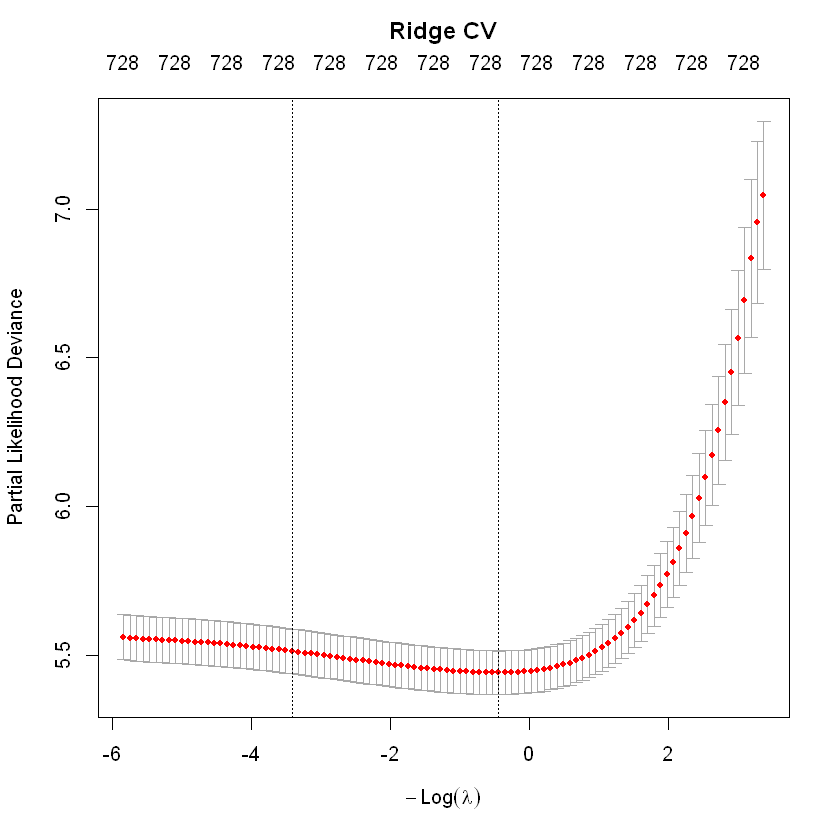

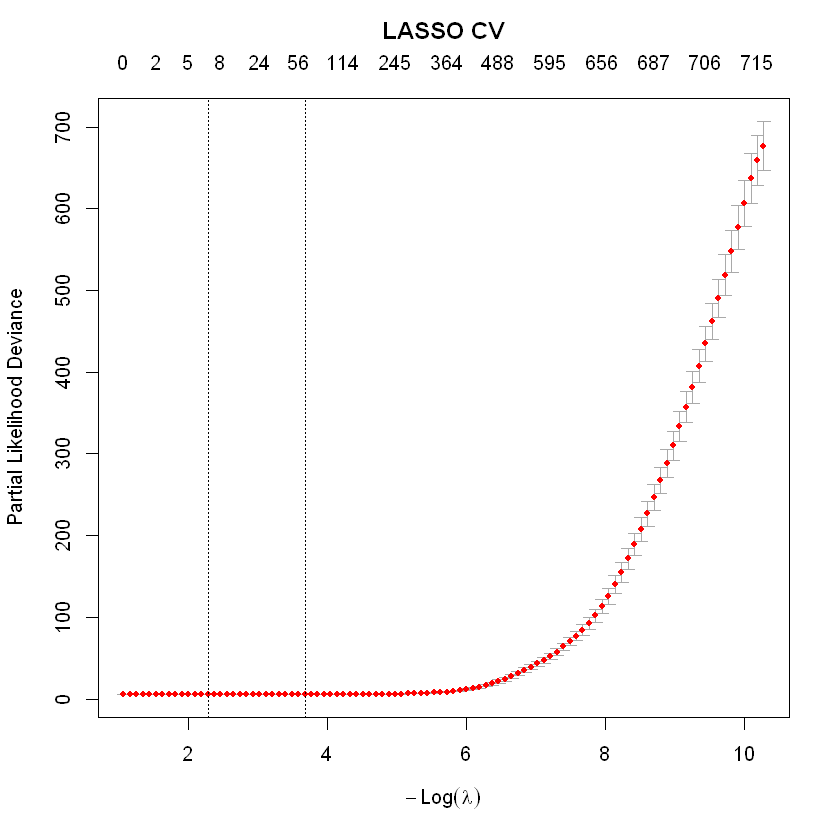

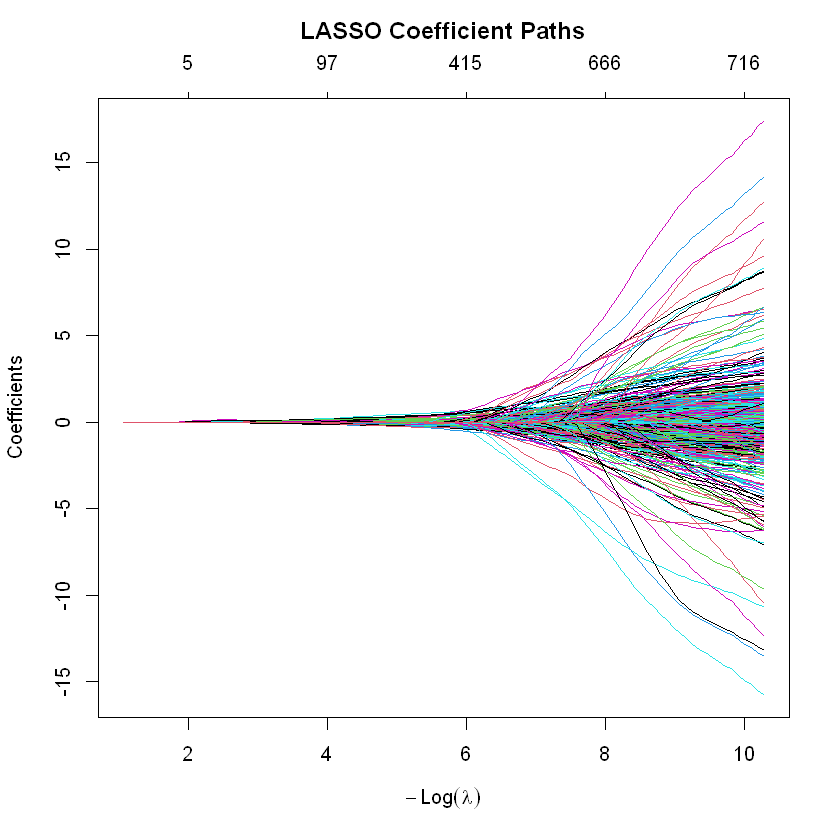

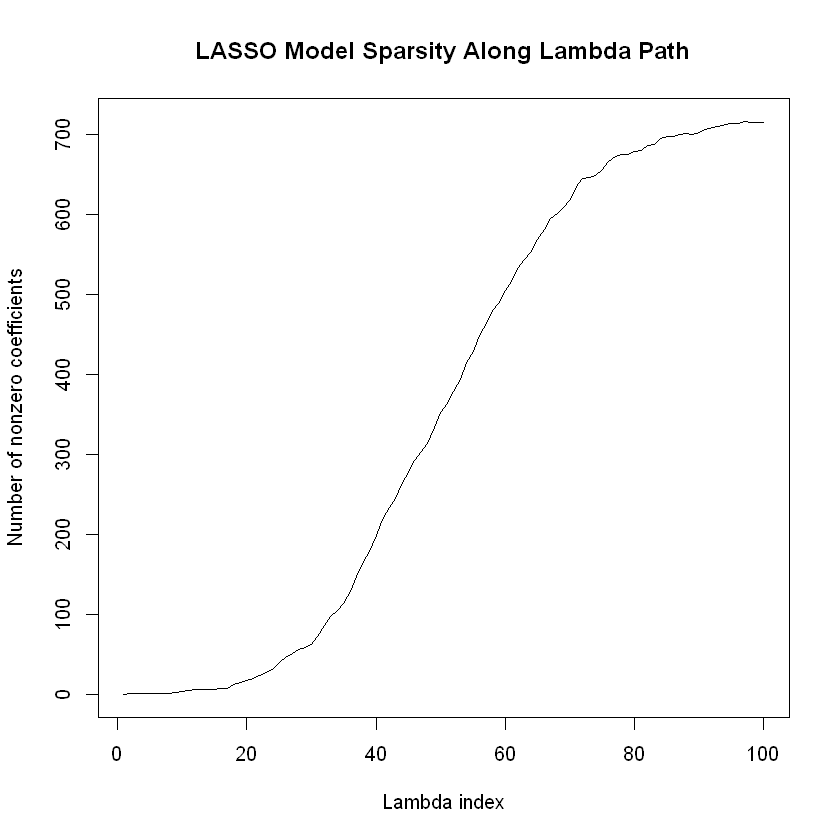

In [53]:
# Plots
plot(cv_ridge)
     title(main = "Ridge CV", line = 2.5)

plot(cv_lasso)
     title(main = "LASSO CV", line = 2.5)

plot(lasso_fit, xvar = "lambda")
     title(main = "LASSO Coefficient Paths", line = 2.5)
     
plot(nonzero_counts, type = "l",
     xlab = "Lambda index",
     ylab = "Number of nonzero coefficients",
     main = "LASSO Model Sparsity Along Lambda Path")

In [54]:
# Final interpretation table for model comparison on dataset.
final_models <- data.frame(
  Model = c(
    "Subset Cox",
    "Stepwise AIC Cox",
    "Stepwise BIC Cox",
    "Ridge Cox",
    "LASSO Cox"
  ),
  
  Predictors = c(
    length(coef(cox_subset)),
    length(coef(cox_aic)),
    length(coef(cox_bic)),
    sum(as.vector(ridge_coef_min) != 0),
    sum(as.vector(lasso_coef_min) != 0)
  ),
  
  Concordance = c(
    summary(cox_subset)$concordance[1],
    summary(cox_aic)$concordance[1],
    summary(cox_bic)$concordance[1],
    ridge_conc_min$concordance,
    lasso_conc_min$concordance
  ),
  
  AIC = c(
    extractAIC(cox_subset)[2],
    extractAIC(cox_aic)[2],
    extractAIC(cox_bic)[2],
    NA,
    NA
  )
)

final_models %>%
  arrange(desc(Concordance))

Model,Predictors,Concordance,AIC
<chr>,<int>,<dbl>,<dbl>
LASSO Cox,59,0.7021035,NA
Ridge Cox,728,0.6837492,NA
Stepwise AIC Cox,25,0.6541424,8904.374
Stepwise BIC Cox,5,0.6331431,8932.053
Subset Cox,28,0.5910522,9024.814


# **Part 3: Model performance evaluation and final choice**